In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import dill

In [2]:
palette = sns.color_palette(['#FED789', '#023743', '#72874E'])#, "#453947"])
palette

[(0.996078431372549, 0.8431372549019608, 0.5372549019607843),
 (0.00784313725490196, 0.21568627450980393, 0.2627450980392157),
 (0.4470588235294118, 0.5294117647058824, 0.3058823529411765)]

In [3]:
palette2 = sns.color_palette(["#D5AE63", "#6E6C81"])
palette2

[(0.8352941176470589, 0.6823529411764706, 0.38823529411764707),
 (0.43137254901960786, 0.4235294117647059, 0.5058823529411764)]

In [4]:
palette3 = sns.color_palette(['#FED789', '#72874E'])
palette3

[(0.996078431372549, 0.8431372549019608, 0.5372549019607843),
 (0.4470588235294118, 0.5294117647058824, 0.3058823529411765)]

In [5]:
with open ('threshold_testing_results_v4.dill', 'rb') as f:
    results_fc_sc = dill.load(f)

results_fc = results_fc_sc['fully_connected']
results_sparser = results_fc_sc['sparser']

In [6]:
rows = []
for metric, values in results_fc.items():
    for value in values:
        rows.append({'metric': metric, 'value': value})
df_fc = pd.long_dataframe = pd.DataFrame(rows)
df_fc['Method'] = 'No thresholding'

rows = []
for metric, values in results_sparser.items():
    for value in values:
        rows.append({'metric': metric, 'value': value})
df_sparser = pd.long_dataframe = pd.DataFrame(rows)
df_sparser['Method'] = 'Matched w/structural'

df_other = pd.concat([df_fc, df_sparser], axis=0)
df_other.head()

,metric,value,Method
0,clustering,0.258103,No thresholding
1,clustering,0.317826,No thresholding
2,clustering,0.472415,No thresholding
3,clustering,0.331661,No thresholding
4,clustering,0.293634,No thresholding


In [14]:
df_other.shape

(9212, 3)

In [8]:
with open ('threshold_testing_results_v3.dill', 'rb') as f:
    results_all = dill.load(f)

results_all.keys()

dict_keys(['all_nodes', 'gcc', 'disparity'])

In [9]:
results_all_nodes = results_all['all_nodes']
results_gcc = results_all['gcc']
results_disp = results_all['disparity']

In [10]:
# Turn results into long df
# All nodes
rows = []
for threshold, metrics in results_all_nodes.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_all = pd.long_dataframe = pd.DataFrame(rows)
df_all['Method'] = 'All nodes (default)'

# GCC
rows = []
for threshold, metrics in results_gcc.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_gcc = pd.long_dataframe = pd.DataFrame(rows)
df_gcc['Method'] = 'GCC'

# Disparity
rows = []
for threshold, metrics in results_disp.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_disp = pd.long_dataframe = pd.DataFrame(rows)
df_disp['Method'] = 'Disparity filter'

In [11]:
df = pd.concat([df_all, df_gcc, df_disp], axis=0)
df = df.dropna()
df.head()

,threshold,metric,value,Method
0,0.05,clustering,0.284401,All nodes (default)
1,0.05,clustering,0.300502,All nodes (default)
2,0.05,clustering,0.316421,All nodes (default)
3,0.05,clustering,0.281511,All nodes (default)
4,0.05,clustering,0.332586,All nodes (default)


In [16]:
df.columns

Index(['threshold', 'metric', 'value', 'Method'], dtype='object')

In [26]:
df_grouped = df.groupby(['metric', 'Method'])['value'].mean().reset_index()
df_grouped.head()

,metric,Method,value
0,clustering,All nodes (default),0.357092
1,clustering,Disparity filter,0.261944
2,clustering,GCC,0.390546
3,delta_C,All nodes (default),0.252848
4,delta_C,Disparity filter,0.327714


In [32]:
# Group together averaged thresholded metrics and other metrics
grouped = pd.concat([df_other, df_grouped], axis=0)

In [33]:
grouped['Method'].nunique()

5

In [7]:
df['Method'].value_counts()

Method
All nodes (default)    46060
GCC                    46060
Disparity filter       46046
Name: count, dtype: int64

In [18]:
df.groupby('metric')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
metric,,,,,,,,
clustering,9869.0,0.336535,0.095074,0.000000,0.278526,0.339465,0.400877,0.623147
delta_C,9819.0,0.252729,0.162646,0.000000,0.139744,0.248750,0.373984,1.000000
delta_L,9867.0,0.279356,0.204950,0.000000,0.119795,0.266550,0.401801,1.000000
density,9869.0,0.301972,0.190958,0.015980,0.148485,0.299989,0.449997,1.000000
edges,9869.0,10323.382511,7059.342412,1.000000,3578.000000,9581.000000,16100.000000,32482.000000
greedy_modularity,9869.0,0.277592,0.156945,0.000000,0.169400,0.232599,0.336723,0.929738
greedy_num_communities,9869.0,11.117438,16.343895,1.000000,3.000000,4.000000,11.000000,117.000000
leiden_modularity,9869.0,0.300045,0.161613,0.000000,0.184061,0.253495,0.373971,0.929738
leiden_num_communities,9869.0,11.517884,16.300600,1.000000,3.000000,5.000000,11.000000,117.000000


In [12]:
swp_vals = df[df['metric'] == 'swp']

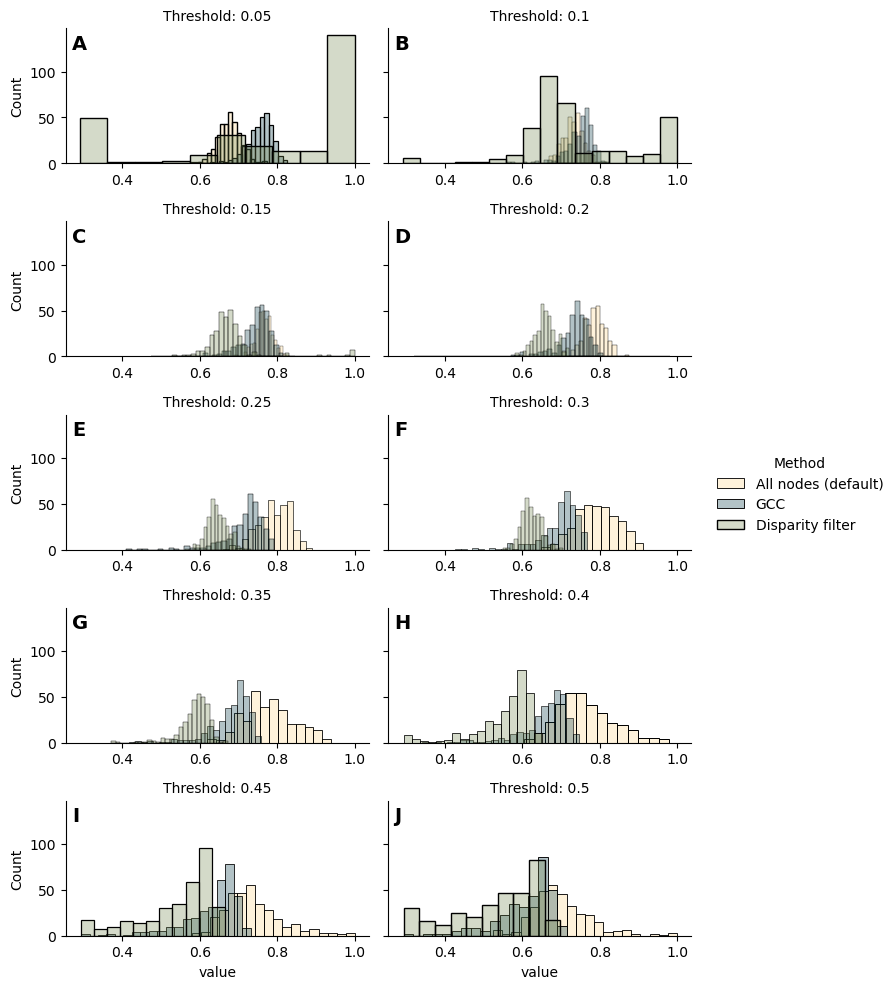

In [15]:
g = sns.FacetGrid(swp_vals, col='threshold', col_wrap=2, hue='Method', palette=palette,
                  height=2, aspect=1.8)
g.map_dataframe(sns.histplot, stat='count', x='value', fill=True, alpha=0.3)
#g.map_dataframe(sns.kdeplot, x='value', fill=False, alpha=0.3)
for ax in g.axes.flat:
    ax.set_xlabel('value')
    ax.tick_params(labelbottom=True)
for ax, label in zip(g.axes.flat, 'ABCDEFGHIJ'):
    ax.annotate(label, xy=(0.02, 0.96), xycoords='axes fraction',
                fontsize=14, fontweight='bold', va='top')
g.add_legend()
g.set_titles(col_template="Threshold: {col_name}")
#g.figure.suptitle("Distribution of SWP by Threshold Level", y=1.02, fontsize=14)
g.tight_layout()
g.savefig('mean_swp_thresholds.png', dpi=200)

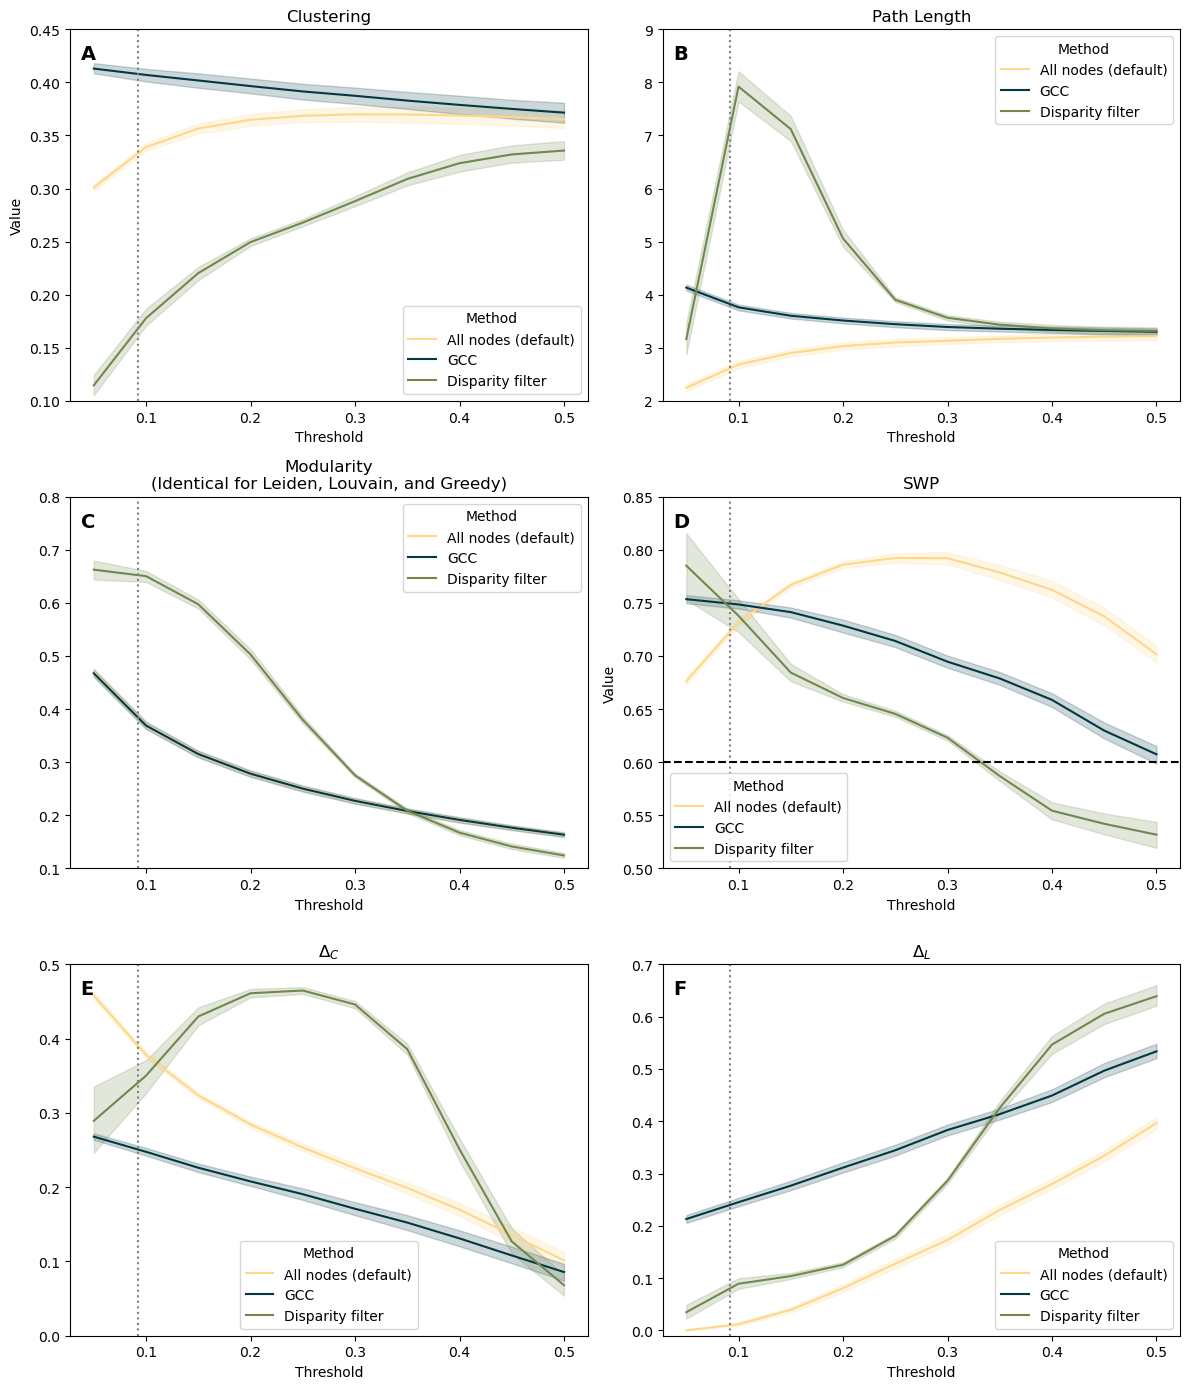

In [16]:
# Plot clustering, path length, and SWP at all threshold levels --
# comparing across all nodes, gcc, and disparity filter
metrics = ['clustering', 'path_length', 'modularity', 'swp', 'delta_C', 'delta_L']
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# Clustering
sns.lineplot(data=df[df['metric'] == 'clustering'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[0, 0], palette=palette)
axes[0, 0].axvline(x=0.092, color='gray', linestyle='dotted')
axes[0, 0].set_title('Clustering')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_ylim(0.1, 0.45)

# Path length
sns.lineplot(data=df[df['metric'] == 'path_length'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[0, 1], palette=palette)
axes[0, 1].axvline(x=0.092, color='gray', linestyle='dotted')
axes[0, 1].set_title('Path Length')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel(None)
axes[0, 1].set_ylim(2, 9)

# Leiden modularity
sns.lineplot(data=df[df['metric'] == 'leiden_modularity'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[1, 0], palette=palette)
axes[1, 0].axvline(x=0.092, color='gray', linestyle='dotted')
axes[1, 0].set_title('Modularity\n(Identical for Leiden, Louvain, and Greedy)')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel(None)
axes[1, 0].set_ylim(0.1, 0.8)

# SWP
sns.lineplot(data=df[df['metric'] == 'swp'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[1, 1], palette=palette)
axes[1, 1].axvline(x=0.092, color='gray', linestyle='dotted')
axes[1, 1].axhline(y=0.6, color='black', linestyle='--')
axes[1, 1].set_title('SWP')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_ylim(0.5, 0.85)

# delta_C
sns.lineplot(data=df[df['metric'] == 'delta_C'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[2, 0], palette=palette)
axes[2, 0].axvline(x=0.092, color='gray', linestyle='dotted')
axes[2, 0].set_title(r'$\Delta_{C}$')
axes[2, 0].set_xlabel('Threshold')
axes[2, 0].set_ylabel(None)
axes[2, 0].set_ylim(0, 0.5)

# delta_L
sns.lineplot(data=df[df['metric'] == 'delta_L'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[2, 1], palette=palette)
axes[2, 1].axvline(x=0.092, color='gray', linestyle='dotted')
axes[2, 1].set_title(r'$\Delta_{L}$')
axes[2, 1].set_xlabel('Threshold')
axes[2, 1].set_ylabel(None)
axes[2, 1].set_ylim(-0.01, 0.7)

for ax, label in zip(axes.flat, 'ABCDEF'):
    ax.annotate(label, xy=(0.02, 0.96), xycoords='axes fraction',
                fontsize=14, fontweight='bold', va='top')
#plt.suptitle('Graph Metrics as a Function of Threshold Level and Filtering Method\n(Lower thresholds are more restrictive)', fontsize=16)

plt.tight_layout()
plt.savefig('combined_threshold_metrics_comparison.png', dpi=200)
plt.show()

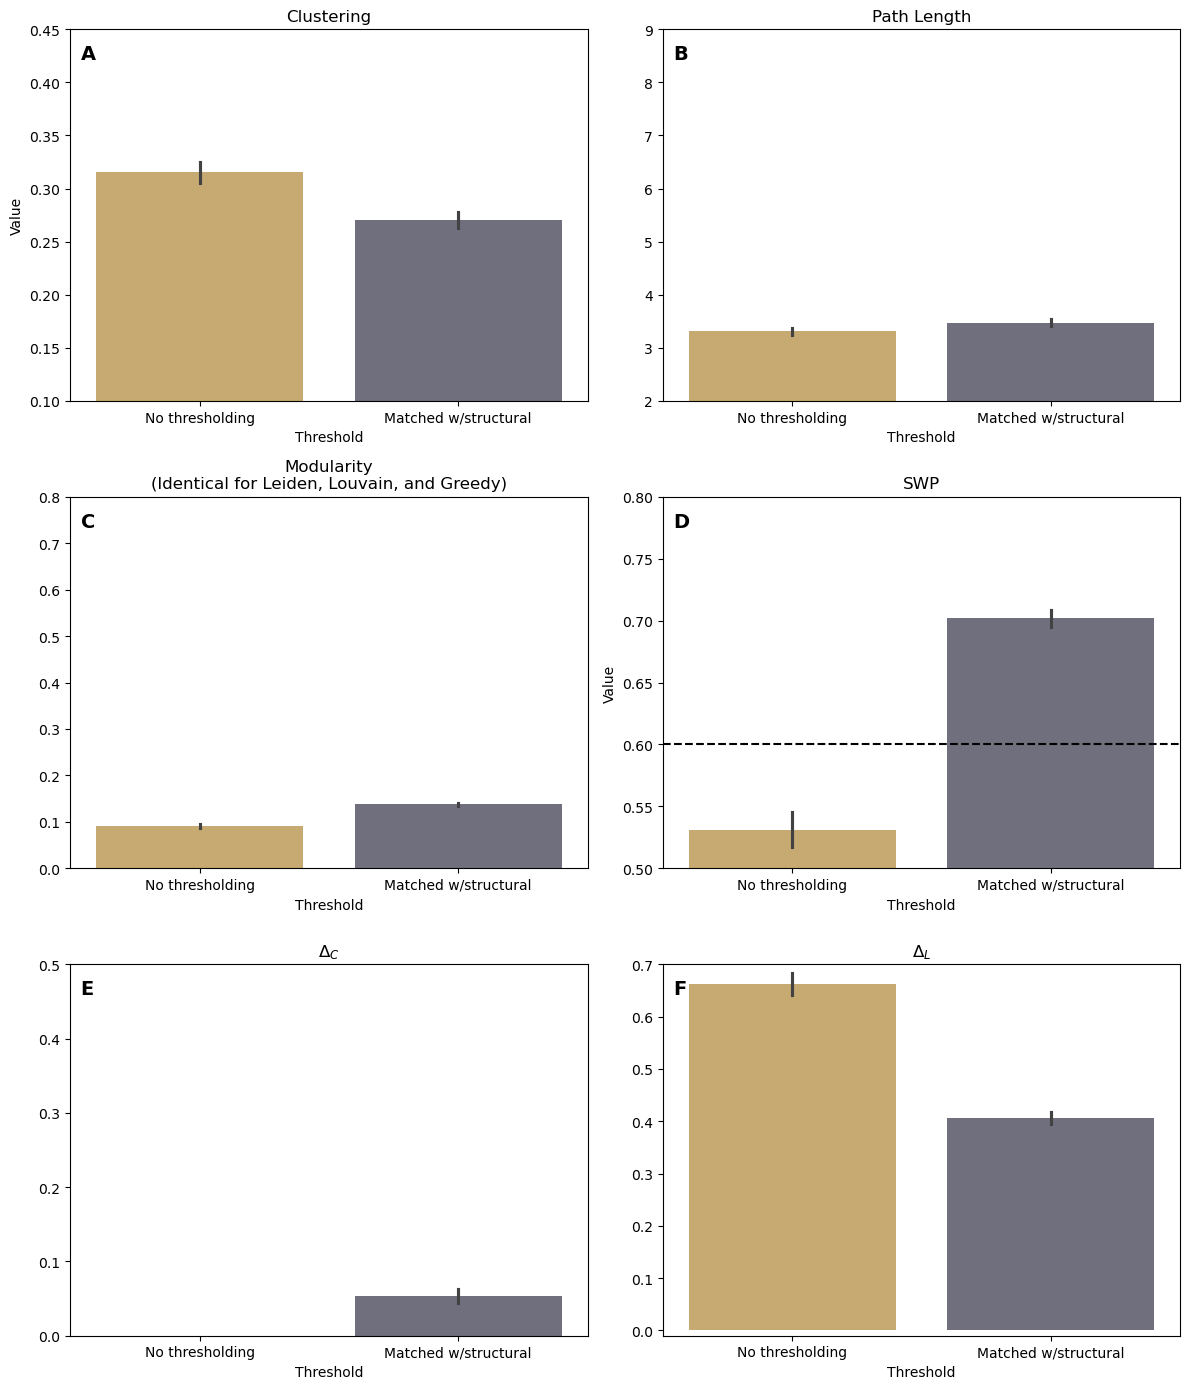

In [7]:
# Plot clustering, path length, and SWP at all threshold levels --
# comparing across all nodes, gcc, and disparity filter
metrics = ['clustering', 'path_length', 'modularity', 'swp', 'delta_C', 'delta_L']
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

# Clustering
sns.barplot(data=df_other[df_other['metric'] == 'clustering'], x='Method', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[0, 0], palette=palette2)
axes[0, 0].set_title('Clustering')
axes[0, 0].set_xlabel('Threshold')
axes[0, 0].set_ylabel('Value')
axes[0, 0].set_ylim(0.1, 0.45)

# Path length
sns.barplot(data=df_other[df_other['metric'] == 'path_length'], x='Method', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[0, 1], palette=palette2)
axes[0, 1].set_title('Path Length')
axes[0, 1].set_xlabel('Threshold')
axes[0, 1].set_ylabel(None)
axes[0, 1].set_ylim(2, 9)

# Leiden modularity
sns.barplot(data=df_other[df_other['metric'] == 'leiden_modularity'], x='Method', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[1, 0], palette=palette2)
axes[1, 0].set_title('Modularity\n(Identical for Leiden, Louvain, and Greedy)')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel(None)
axes[1, 0].set_ylim(0, 0.8)

# SWP
sns.barplot(data=df_other[df_other['metric'] == 'swp'], x='Method', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[1, 1], palette=palette2)
axes[1, 1].axhline(y=0.6, color='black', linestyle='--')
axes[1, 1].set_title('SWP')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_ylim(0.5, 0.8)

# delta_C
sns.barplot(data=df_other[df_other['metric'] == 'delta_C'], x='Method', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[2, 0], palette=palette2)
axes[2, 0].set_title(r'$\Delta_{C}$')
axes[2, 0].set_xlabel('Threshold')
axes[2, 0].set_ylabel(None)
axes[2, 0].set_ylim(0, 0.5)

# delta_L
sns.barplot(data=df_other[df_other['metric'] == 'delta_L'], x='Method', y='value',
             errorbar=('ci', 95), hue='Method', ax=axes[2, 1], palette=palette2)
axes[2, 1].set_title(r'$\Delta_{L}$')
axes[2, 1].set_xlabel('Threshold')
axes[2, 1].set_ylabel(None)
axes[2, 1].set_ylim(-0.01, 0.7)

for ax, label in zip(axes.flat, 'ABCDEF'):
    ax.annotate(label, xy=(0.02, 0.96), xycoords='axes fraction',
                fontsize=14, fontweight='bold', va='top')
#plt.suptitle('Graph Metrics -- No Threshold vs Matching with Structural Connectivity', fontsize=16)

plt.tight_layout()
plt.savefig('combined_metrics_fc_sc_comparison.png', dpi=200)
plt.show()

In [17]:
with open ('threshold_testing_results_v5_connectivity.dill', 'rb') as f:
    results_all = dill.load(f)

results_all_nodes = results_all['all_nodes']
results_gcc = results_all['gcc']
results_disp = results_all['disparity']

# Turn results into long df
"""
# All nodes
rows = []
for threshold, metrics in results_all_nodes.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_all = pd.long_dataframe = pd.DataFrame(rows)
df_all['Method'] = 'All nodes (default)'
"""
# GCC
rows = []
for threshold, metrics in results_gcc.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_gcc = pd.long_dataframe = pd.DataFrame(rows)
df_gcc['Method'] = 'All nodes/GCC'

# Disparity
rows = []
for threshold, metrics in results_disp.items():
    for metric, values in metrics.items():
        for value in values:
            rows.append({'threshold': threshold, 'metric': metric, 'value': value})

df_disp = pd.long_dataframe = pd.DataFrame(rows)
df_disp['Method'] = 'Disparity filter'

In [18]:
#df = pd.concat([df_all, df_gcc, df_disp], axis=0)
df = pd.concat([df_gcc, df_disp], axis=0)
df = df.dropna()
df.head()

,threshold,metric,value,Method
0,0.05,connectivity,0.674424,All nodes/GCC
1,0.05,connectivity,0.702283,All nodes/GCC
2,0.05,connectivity,0.791087,All nodes/GCC
3,0.05,connectivity,0.711675,All nodes/GCC
4,0.05,connectivity,0.701562,All nodes/GCC


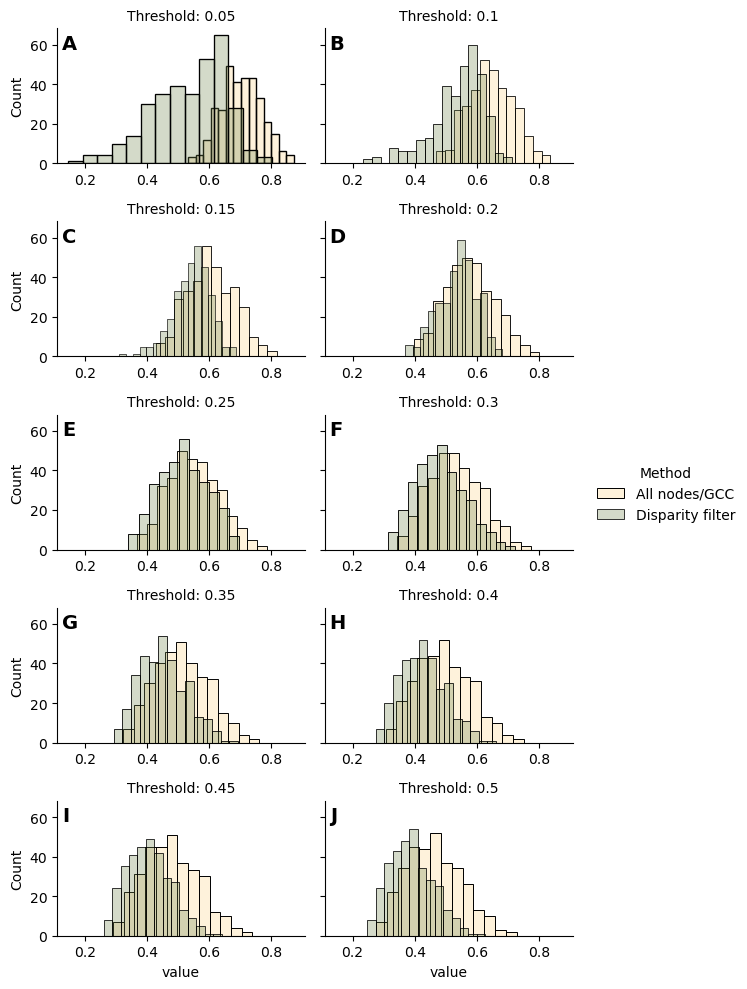

In [19]:
g = sns.FacetGrid(df, col='threshold', col_wrap=2, hue='Method', palette=palette3,
                  height=2, aspect=1.5)
g.map_dataframe(sns.histplot, stat='count', x='value', fill=True, alpha=0.3)
#g.map_dataframe(sns.kdeplot, x='value', fill=False, alpha=0.3)
for ax in g.axes.flat:
    ax.set_xlabel('value')
    ax.tick_params(labelbottom=True)
for ax, label in zip(g.axes.flat, 'ABCDEFGHIJ'):
    ax.annotate(label, xy=(0.02, 0.96), xycoords='axes fraction',
                fontsize=14, fontweight='bold', va='top')
g.add_legend()
g.set_titles(col_template="Threshold: {col_name}")
#g.figure.suptitle("Distribution of Overall Functional Connectivity by Threshold Level", y=1.02, fontsize=14)
g.tight_layout()
g.savefig('mean_connectivity_thresholds.png', dpi=200)

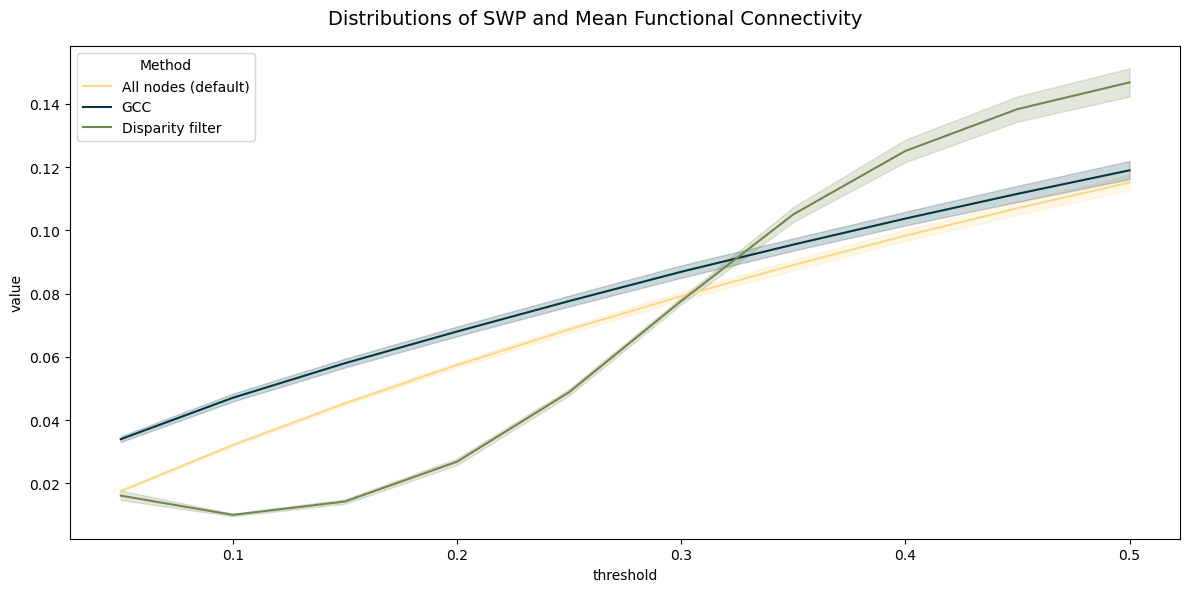

In [17]:
fig, axes = plt.subplots(1, figsize=(12, 6))


s
sns.lineplot(data=df[df['metric'] == 'connectivity'], x='threshold', y='value',
             errorbar=('ci', 95), hue='Method', palette=palette)#, ax=axes[0])
#axes[0].axvline(x=0.6, color='black', linestyle='--', label='Small-World Threshold')
#axes[0].set_title('SWP')
#axes[0].set_xlabel('SWP')
"""
sns.histplot(data=df[df['metric'] == 'connectivity'], x='value', stat='count',
             hue='Method', palette=palette, ax=axes[1])
axes[1].set_title('Mean Functional Connectivity')
axes[1].set_xlabel('Weight')

for ax, label in zip(axes.flat, 'A'):
    ax.annotate(label, xy=(0.02, 0.96), xycoords='axes fraction',
                fontsize=14, fontweight='bold', va='top')
"""
plt.suptitle('Distributions of SWP and Mean Functional Connectivity', fontsize=14)
plt.tight_layout()
#plt.savefig('swp_connectivity_dist_fc_struc.png')
plt.show()